In [1]:
# 1. Install the required tools first!
!pip install kagglehub opencv-python ultralytics
# kagglehub=>tool to fetch datasets from kaggle
#opencv-python=>tool used to reading and manipulate images

# 2. Bring in the kaggle tool
import kagglehub

# 3. Download the dataset
path = kagglehub.dataset_download("fareselmenshawii/face-detection-dataset")

print("Path to dataset files:", path)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 9.4 MB/s eta 0:00:00


100%|██████████| 4.43G/4.43G [00:36<00:00, 132MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import kagglehub

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Number of files:", len(files))
    print("-" * 50)

/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3
Number of files: 0
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images
Number of files: 0
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train
Number of files: 13386
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/val
Number of files: 3347
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/labels2
Number of files: 16733
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/labels
Number of files: 0
--------------------------------------------------
/root/.cache/kagglehub/da

In [4]:
image_files = []
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_files.append(os.path.join(root, file))

print("Total Images Found:", len(image_files))

Total Images Found: 16733


In [5]:
import random

selected_images = random.sample(    #Randomly pulls exactly 4,000 unique image paths from the full image_files
    image_files,
    min(4000, len(image_files))  #selecting minimum photos
)

print("Images Selected:", len(selected_images))

Images Selected: 4000


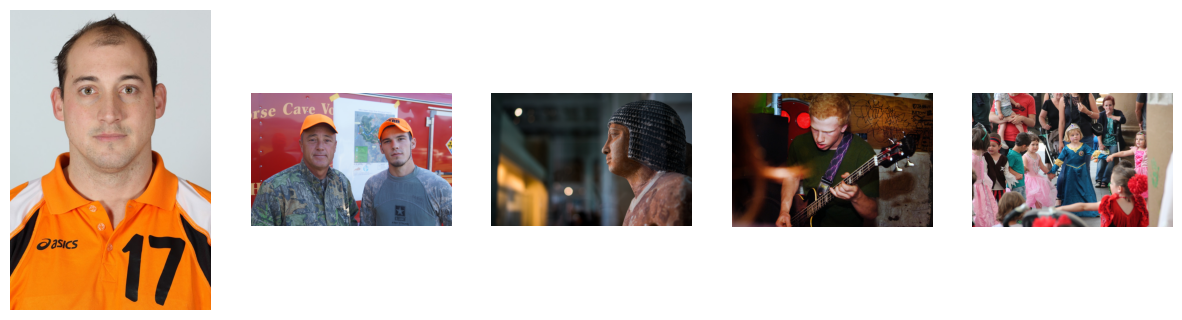

In [6]:
import cv2
import matplotlib.pyplot as plt

sample_images = random.sample(selected_images, 5)

plt.figure(figsize=(15, 8))

for i, img_path in enumerate(sample_images):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")


image 1/1 /root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train/3dc05af201d5ade8.jpg: 640x448 1 person, 7.4ms
Speed: 100.9ms preprocess, 7.4ms inference, 44.0ms postprocess per image at shape (1, 3, 640, 448)


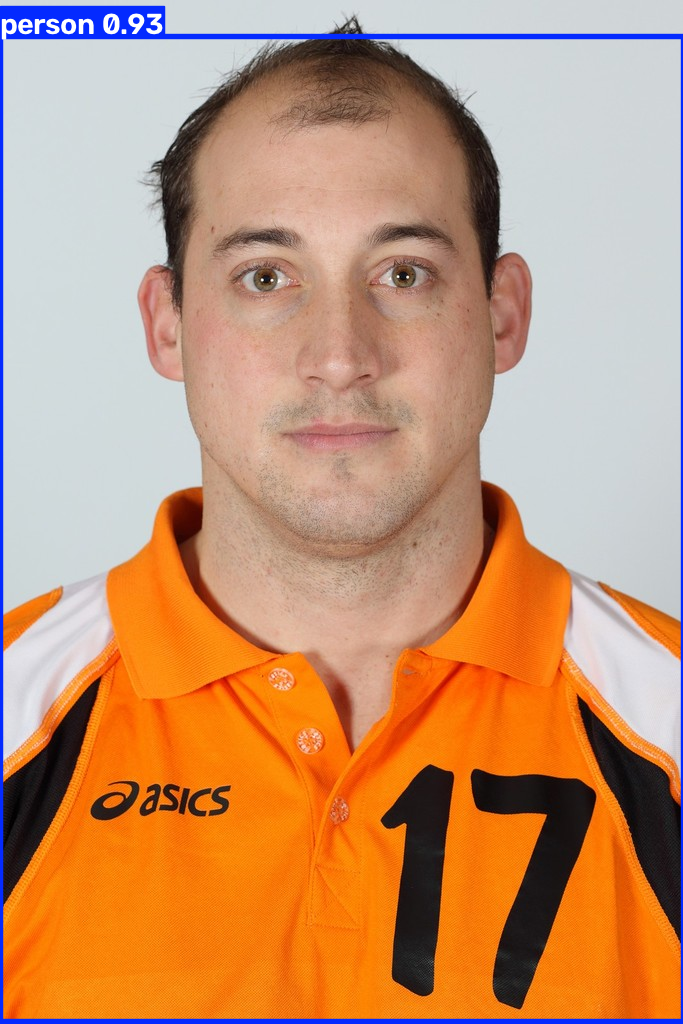

In [10]:
img_path = sample_images[0]
results = model(img_path)
results[0].show()


image 1/1 /root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train/3dc05af201d5ade8.jpg: 640x448 1 person, 7.5ms
Speed: 2.0ms preprocess, 7.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 448)


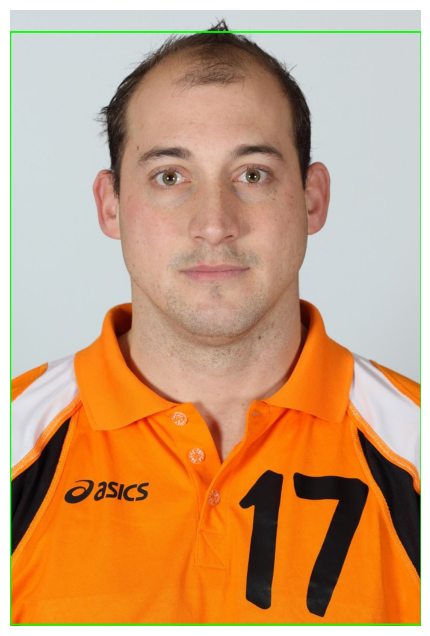

In [11]:
img = cv2.imread(img_path)
results = model(img_path)

for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
from google.colab import files

uploaded = files.upload()

Saving p1.jpeg to p1 (1).jpeg
Saving p2.webp to p2.webp
Saving p3.avif to p3.avif
Saving p4.jpg to p4.jpg



image 1/1 /content/p1 (1).jpeg: 256x640 8 persons, 86.1ms
Speed: 1.7ms preprocess, 86.1ms inference, 4.7ms postprocess per image at shape (1, 3, 256, 640)


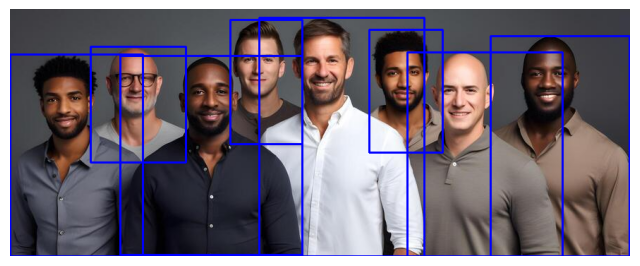

In [14]:
uploaded_file = list(uploaded.keys())[0]

img = cv2.imread(uploaded_file)

results = model(uploaded_file)

for box in results[0].boxes.xyxy:

    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(
        img,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2
    )

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [15]:
results = model(uploaded_file)

num_faces = len(results[0].boxes)

print("Number of Faces Detected:", num_faces)


image 1/1 /content/p1 (1).jpeg: 256x640 8 persons, 6.5ms
Speed: 1.3ms preprocess, 6.5ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 640)
Number of Faces Detected: 8


In [16]:
import os

# Ensure path is defined correctly based on the dataset location
path = '/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3'

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images
[]
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/train
['0ed60f26bf97ba14.jpg', '3e02a45c9acd6f1c.jpg', 'e74633e10967529c.jpg', 'c7afd3798cc9af6e.jpg', '12a41127a9976820.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/val
['d73abf5bdc9957bb.jpg', 'fa2d8e0e59f9dc01.jpg', '3e1a6687e49906fe.jpg', 'bf74b84f3947e378.jpg', 'd4e53dc3ce5fcc4a.jpg']
--------------------------------------------------
/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/labels2
['3523b08dee4486fa.txt', 'a8e3cb29b69b6d68.txt', 'dfa2fdc7920d6619.txt', '1096e6f6fd042a04.txt

In [17]:
import torch

print("GPU Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

GPU Available: True
GPU Name: Tesla T4


In [18]:
import os
import shutil
import random

base_path = "/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3"

train_img_dir = os.path.join(base_path, "images/train")
train_lbl_dir = os.path.join(base_path, "labels/train")

subset_img_dir = "/content/face_subset/images/train"
subset_lbl_dir = "/content/face_subset/labels/train"

os.makedirs(subset_img_dir, exist_ok=True)
os.makedirs(subset_lbl_dir, exist_ok=True)

all_images = [f for f in os.listdir(train_img_dir) if f.endswith(".jpg")]

selected_images = random.sample(all_images, min(4000, len(all_images)))

for img_file in selected_images:
    shutil.copy(
        os.path.join(train_img_dir, img_file),
        os.path.join(subset_img_dir, img_file)
    )
    label_file = img_file.replace(".jpg", ".txt")
    if os.path.exists(os.path.join(train_lbl_dir, label_file)):
        shutil.copy(
            os.path.join(train_lbl_dir, label_file),
            os.path.join(subset_lbl_dir, label_file)
        )

print("4000-image subset created!")

4000-image subset created!


In [19]:
print(path)

/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3


In [20]:
import kagglehub

path = kagglehub.dataset_download(
    "fareselmenshawii/face-detection-dataset"
)

print(path)

Using Colab cache for faster access to the 'face-detection-dataset' dataset.
/kaggle/input/face-detection-dataset


### Model Training
Now that we have prepared our dataset subset, we can proceed to train the YOLOv8 model. We will create a small YAML configuration file to point the trainer to our local data paths.

In [21]:
import yaml

# Define the dataset configuration
data_config = {
    'train': '/content/face_subset/images/train',
    'val': '/root/.cache/kagglehub/datasets/fareselmenshawii/face-detection-dataset/versions/3/images/val',
    'nc': 1,
    'names': ['face']
}

# Save the configuration to a YAML file
with open('face_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

print("Dataset configuration file 'face_data.yaml' created.")

Dataset configuration file 'face_data.yaml' created.


In [22]:
from ultralytics import YOLO

# Initialize the model (ensure it's defined before training)
model = YOLO('yolov8n.pt')

# Start training the model
# We'll train for a few epochs as a demonstration
results = model.train(
    data='face_data.yaml',
    epochs=5,
    imgsz=640,
    batch=16,
    project='face_detection_run',
    name='yolov8n_faces'
)

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=face_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_faces, nbs=64, nms=None, opset=None, optimize=False, op

### Model Evaluation and Inference
We can now load the 'best' weights from our training session and test the model on an image.

In [24]:
import glob

# Find the path to the best weights automatically
run_dir = "/content/runs/detect/face_detection_run/yolov8n_faces"
best_model_path = f"{run_dir}/weights/best.pt"

# Load the fine-tuned model
fine_tuned_model = YOLO(best_model_path)
print(f"Loaded fine-tuned model from: {best_model_path}")

Loaded fine-tuned model from: /content/runs/detect/face_detection_run/yolov8n_faces/weights/best.pt



image 1/1 /content/p1.jpeg: 256x640 8 faces, 7.6ms
Speed: 2.0ms preprocess, 7.6ms inference, 1.6ms postprocess per image at shape (1, 3, 256, 640)


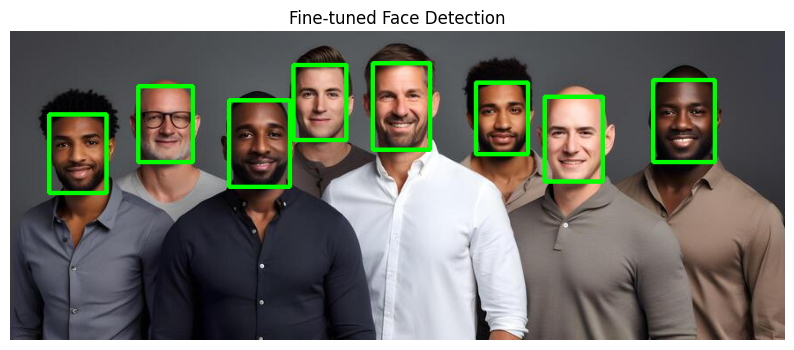

Faces detected with fine-tuned model: 8


In [26]:
import cv2
import matplotlib.pyplot as plt

# Re-identify the uploaded file if the variable was lost
uploaded_file = 'p1.jpeg'

# Run inference on the uploaded image using the fine-tuned model
results_ft = fine_tuned_model(uploaded_file)

# Visualize the results
img_ft = cv2.imread(uploaded_file)
img_ft = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)

for box in results_ft[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_ft, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(10,10))
plt.imshow(img_ft)
plt.title("Fine-tuned Face Detection")
plt.axis("off")
plt.show()

print(f"Faces detected with fine-tuned model: {len(results_ft[0].boxes)}")

### Comparison: Base Model vs. Fine-tuned Model
Finally, let's compare the original model's detections with our new fine-tuned model results on the same image.


image 1/1 /content/p1.jpeg: 256x640 8 faces, 5.5ms
Speed: 1.1ms preprocess, 5.5ms inference, 1.2ms postprocess per image at shape (1, 3, 256, 640)

image 1/1 /content/p1.jpeg: 256x640 8 faces, 7.0ms
Speed: 1.7ms preprocess, 7.0ms inference, 1.3ms postprocess per image at shape (1, 3, 256, 640)


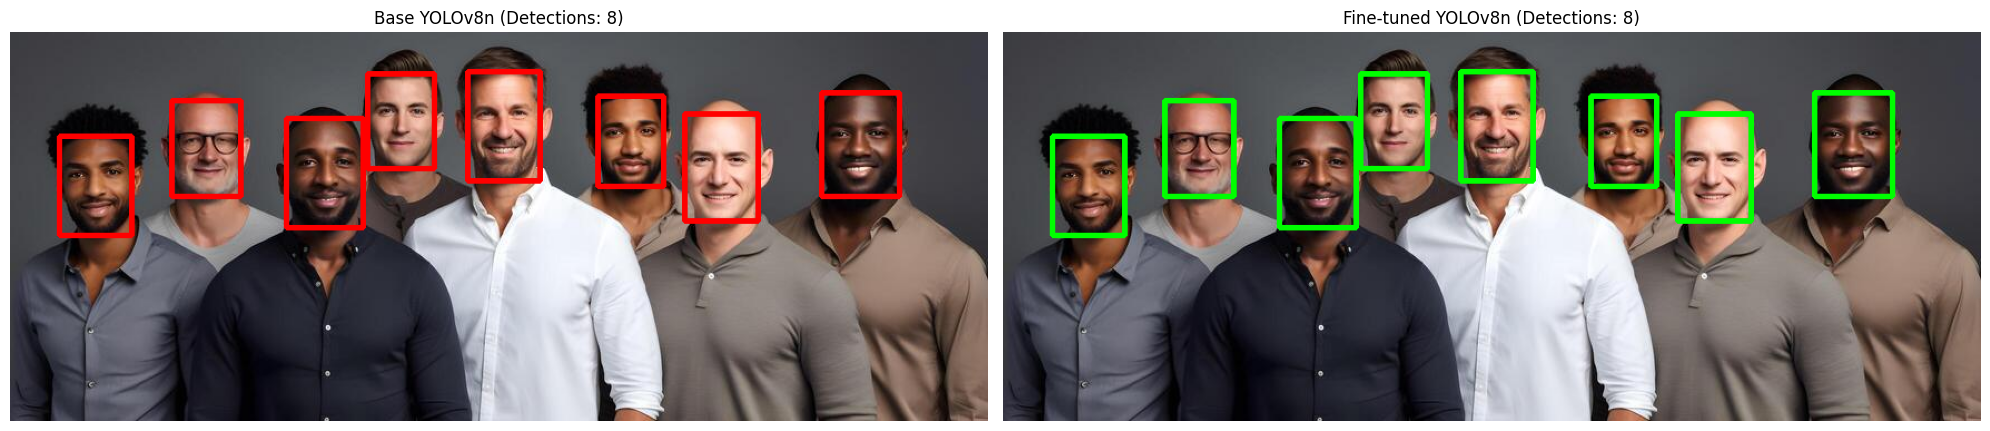

In [27]:
import cv2
import matplotlib.pyplot as plt

# 1. Get results from base model
base_results = model(uploaded_file)
img_base = cv2.imread(uploaded_file)
img_base = cv2.cvtColor(img_base, cv2.COLOR_BGR2RGB)
for box in base_results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_base, (x1, y1), (x2, y2), (255, 0, 0), 3)

# 2. Get results from fine-tuned model
ft_results = fine_tuned_model(uploaded_file)
img_ft = cv2.imread(uploaded_file)
img_ft = cv2.cvtColor(img_ft, cv2.COLOR_BGR2RGB)
for box in ft_results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_ft, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(img_base)
axes[0].set_title(f"Base YOLOv8n (Detections: {len(base_results[0].boxes)})")
axes[0].axis('off')
axes[1].imshow(img_ft)
axes[1].set_title(f"Fine-tuned YOLOv8n (Detections: {len(ft_results[0].boxes)})")
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [28]:
from google.colab import files
# Download your custom-trained YOLO model
files.download('/content/runs/detect/face_detection_run/yolov8n_faces/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
!pip install deepface


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.6/205.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.7 MB/s eta 0:00:00



image 1/1 /content/p1.jpeg: 256x640 8 faces, 58.1ms
Speed: 14.3ms preprocess, 58.1ms inference, 8.2ms postprocess per image at shape (1, 3, 256, 640)
26-09-19 13:24:30 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 113MB/s]


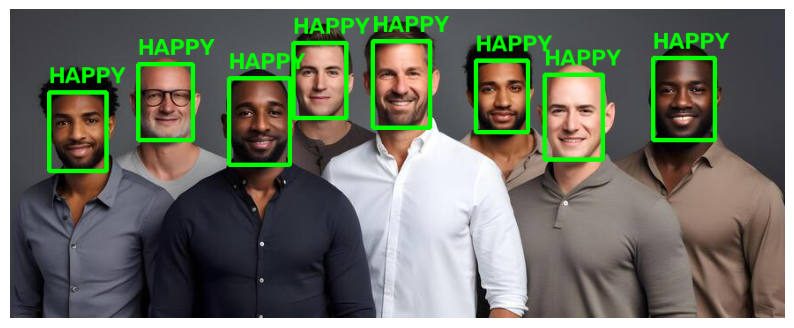

In [31]:
from deepface import DeepFace
import cv2
import matplotlib.pyplot as plt

# 1. Load the picture and run your custom YOLO face-finder
img = cv2.imread(uploaded_file)
results = fine_tuned_model(uploaded_file)

# 2. Loop through every face YOLO found
for box in results[0].boxes.xyxy:
    x1, y1, x2, y2 = map(int, box)

    # Crop just the face out of the picture
    face_crop = img[y1:y2, x1:x2]

    # 3. Ask DeepFace to read the emotion of the cropped face
    try:
        # ADDED: detector_backend="skip" prevents DeepFace from over-detecting
        analysis = DeepFace.analyze(face_crop, actions=['emotion'], enforce_detection=False, detector_backend="skip")
        dominant_emotion = analysis[0]['dominant_emotion']
    except Exception as e:
        # ADDED: This will print the actual error instead of hiding it!
        print(f"Error analyzing face at ({x1}, {y1}):", e)
        dominant_emotion = "Unknown"

    # 4. Draw the green box AND write the emotion above the face!
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    cv2.putText(img, dominant_emotion.upper(), (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# 5. Show the final Masterpiece!
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


==================== RESULTS FOR: p1.jpeg ====================

image 1/1 /content/p1.jpeg: 256x640 8 faces, 8.5ms
Speed: 1.5ms preprocess, 8.5ms inference, 1.5ms postprocess per image at shape (1, 3, 256, 640)
Total Faces Found: 8
  Face #1: HAPPY | Confidence: 100.00%
  Face #2: HAPPY | Confidence: 96.23%
  Face #3: HAPPY | Confidence: 87.52%
  Face #4: HAPPY | Confidence: 99.17%
  Face #5: HAPPY | Confidence: 100.00%
  Face #6: HAPPY | Confidence: 93.48%
  Face #7: HAPPY | Confidence: 97.53%
  Face #8: HAPPY | Confidence: 99.57%


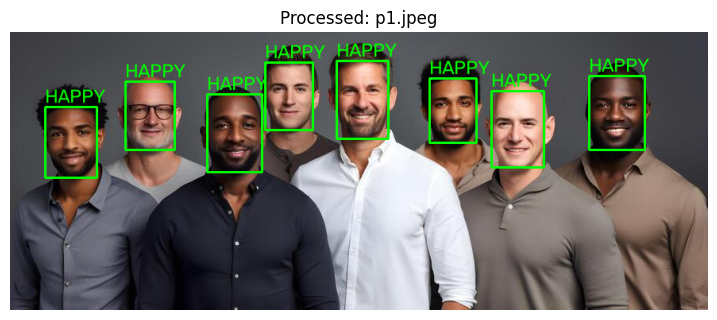


==================== RESULTS FOR: p2.webp ====================

image 1/1 /content/p2.webp: 352x640 6 faces, 7.4ms
Speed: 1.9ms preprocess, 7.4ms inference, 1.4ms postprocess per image at shape (1, 3, 352, 640)
Total Faces Found: 6
  Face #1: ANGRY | Confidence: 50.61%
  Face #2: ANGRY | Confidence: 85.70%
  Face #3: ANGRY | Confidence: 90.20%
  Face #4: FEAR | Confidence: 90.83%
  Face #5: SAD | Confidence: 90.41%
  Face #6: SAD | Confidence: 99.99%


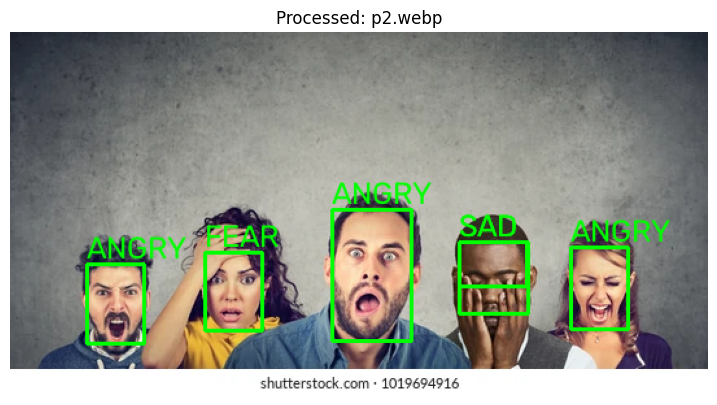


==================== RESULTS FOR: p3.avif ====================

image 1/1 /content/p3.avif: 640x448 1 face, 8.1ms
Speed: 2.5ms preprocess, 8.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 448)
Total Faces Found: 1
  Face #1: NEUTRAL | Confidence: 99.85%


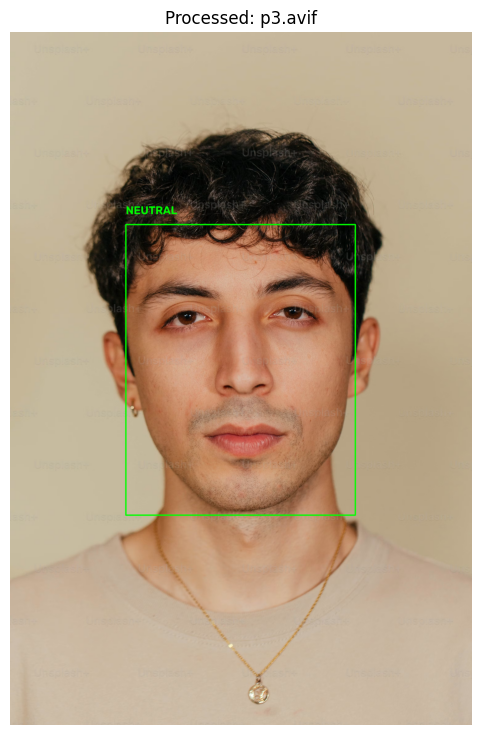


==================== RESULTS FOR: p4.jpg ====================

image 1/1 /content/p4.jpg: 640x448 1 face, 10.6ms
Speed: 4.9ms preprocess, 10.6ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 448)
Total Faces Found: 1
  Face #1: NEUTRAL | Confidence: 99.76%


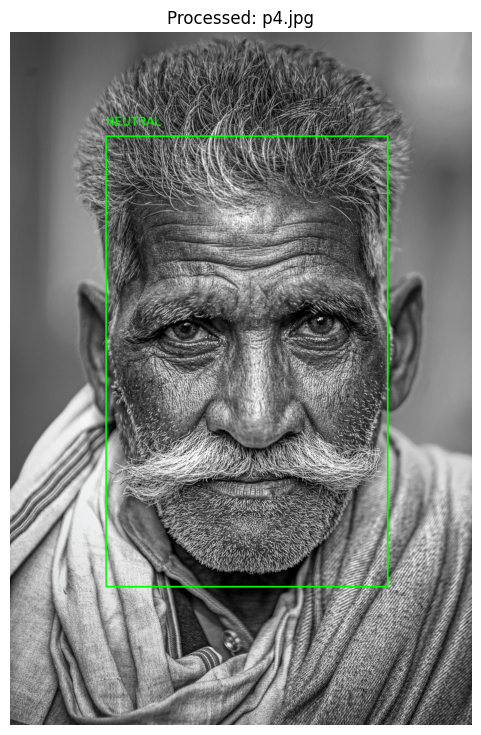

In [33]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace

# List of all uploaded test images
test_images = ['p1.jpeg', 'p2.webp', 'p3.avif', 'p4.jpg']

for img_name in test_images:
    if not os.path.exists(img_name):
        continue

    print(f"\n==================== RESULTS FOR: {img_name} ====================")

    # 1. Load image using PIL to safely support .avif, .webp, and high resolutions
    pil_img = Image.open(img_name).convert('RGB')
    img = np.array(pil_img)
    h, w, _ = img.shape

    # 2. Run your fine-tuned YOLO face detector
    results = fine_tuned_model(img_name)
    boxes = results[0].boxes.xyxy

    print(f"Total Faces Found: {len(boxes)}")

    # Dynamic scaling for text and box borders based on image dimensions
    font_scale = max(w / 1200, 0.8)
    box_thickness = max(int(w / 400), 2)
    font_thickness = max(int(box_thickness / 1.5), 1)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)

        # Crop the face safely within image boundaries
        face_crop = img[max(0, y1):min(h, y2), max(0, x1):min(w, x2)]
        if face_crop.size == 0:
            continue

        # 3. Analyze emotion with DeepFace
        try:
            analysis = DeepFace.analyze(
                face_crop,
                actions=['emotion'],
                enforce_detection=False,
                detector_backend="skip"
            )
            dominant = analysis[0]['dominant_emotion']
            scores = analysis[0]['emotion']
        except Exception as e:
            dominant = "Unknown"
            scores = {}

        # Print detailed scores to the console
        print(f"  Face #{i+1}: {dominant.upper()} | Confidence: {scores.get(dominant, 0):.2f}%")

        # 4. Draw bounding box & text
        text = dominant.upper()
        text_y = max(y1 - int(h * 0.015), int(h * 0.04))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), box_thickness)
        cv2.putText(
            img,
            text,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 255, 0),
            font_thickness
        )

    # 5. Display visual result
    plt.figure(figsize=(9, 9))
    plt.imshow(img)
    plt.title(f"Processed: {img_name}")
    plt.axis("off")
    plt.show()

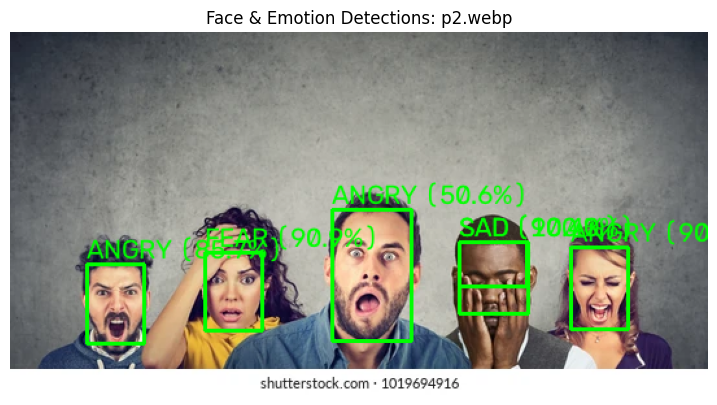

,Face #,Dominant Emotion,Confidence (%),"Box (x1, y1, x2, y2)"
0,1,Angry,50.610001,"(248, 137, 309, 238)"
1,2,Angry,85.699997,"(59, 179, 103, 240)"
2,3,Angry,90.199997,"(432, 166, 476, 229)"
3,4,Fear,90.889999,"(150, 170, 194, 230)"
4,5,Sad,90.410004,"(346, 162, 399, 217)"
5,6,Sad,99.989998,"(346, 162, 398, 196)"


In [34]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace

def analyze_face_emotions(image_path, model, conf_threshold=0.25):
    """
    End-to-end pipeline:
    1. Detects faces using the fine-tuned YOLO model.
    2. Crops and classifies emotion for each detected face using DeepFace.
    3. Renders bounding boxes and labels onto the image.
    4. Returns a summary DataFrame of all detections.
    """
    if not os.path.exists(image_path):
        print(f"Error: File '{image_path}' not found.")
        return None

    # Load image using PIL for format compatibility (.avif, .webp, .jpg)
    pil_img = Image.open(image_path).convert("RGB")
    img = np.array(pil_img)
    h, w, _ = img.shape

    # 1. YOLO face detection inference
    results = model(image_path, conf=conf_threshold, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    # Dynamic styling for labels
    font_scale = max(w / 1200, 0.7)
    box_thickness = max(int(w / 400), 2)
    font_thickness = max(int(box_thickness / 1.5), 1)

    records = []

    # 2. Iterate through each detected face
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box)

        # Safe coordinate bounds
        crop_x1, crop_y1 = max(0, x1), max(0, y1)
        crop_x2, crop_y2 = min(w, x2), min(h, y2)
        face_crop = img[crop_y1:crop_y2, crop_x1:crop_x2]

        if face_crop.size == 0:
            continue

        # 3. Emotion classification
        try:
            analysis = DeepFace.analyze(
                face_crop,
                actions=['emotion'],
                enforce_detection=False,
                detector_backend="skip"
            )
            dominant = analysis[0]['dominant_emotion']
            confidence = analysis[0]['emotion'].get(dominant, 0.0)
        except Exception:
            dominant = "Unknown"
            confidence = 0.0

        records.append({
            "Face #": i + 1,
            "Dominant Emotion": dominant.capitalize(),
            "Confidence (%)": round(confidence, 2),
            "Box (x1, y1, x2, y2)": (x1, y1, x2, y2)
        })

        # 4. Draw annotations
        label = f"{dominant.upper()} ({confidence:.1f}%)"
        text_y = max(y1 - int(h * 0.015), int(h * 0.04))

        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), box_thickness)
        cv2.putText(
            img,
            label,
            (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            font_scale,
            (0, 255, 0),
            font_thickness
        )

    # 5. Display visualization
    plt.figure(figsize=(9, 9))
    plt.imshow(img)
    plt.title(f"Face & Emotion Detections: {os.path.basename(image_path)}")
    plt.axis("off")
    plt.show()

    # 6. Return structured report
    df_results = pd.DataFrame(records)
    return df_results

# Example test call:
report_df = analyze_face_emotions('p2.webp', fine_tuned_model)
display(report_df)

Click 'Choose Files' to upload an image from your computer:


Saving ChatGPT Image Sep 19, 2026, 12_55_02 PM.png to ChatGPT Image Sep 19, 2026, 12_55_02 PM.png

Analyzing: ChatGPT Image Sep 19, 2026, 12_55_02 PM.png


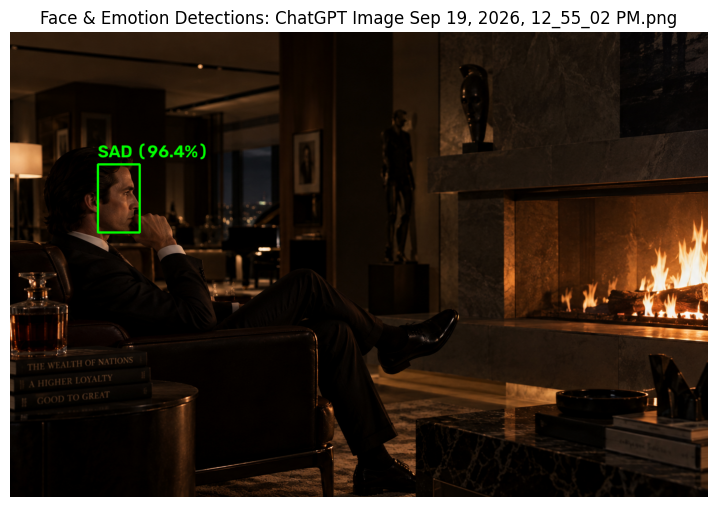

,Face #,Dominant Emotion,Confidence (%),"Box (x1, y1, x2, y2)"
0,1,Sad,96.43,"(193, 291, 285, 441)"


In [35]:
from google.colab import files

print("Click 'Choose Files' to upload an image from your computer:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nAnalyzing: {filename}")
    report_df = analyze_face_emotions(filename, fine_tuned_model)

    if report_df is not None and not report_df.empty:
        display(report_df)
    else:
        print(f"No faces detected in {filename}.")